# Import and/or install libraries: 

In [72]:
import numpy as np

from pathlib import Path
from struct import unpack

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# Load data:

## Read data

In [83]:
# Load NASA reference (512x512)

# Create coordinate grids (512x512)
n_points_nasa = 512
dx_nasa = 2 * np.pi / n_points_nasa
x_nasa = np.arange(-np.pi, np.pi - dx_nasa, dx_nasa)
y_nasa = np.arange(-np.pi, np.pi - dx_nasa, dx_nasa)

# Load binary data
data_file_nasa = Path(
    "../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out"
)
with open(data_file_nasa, "rb") as file:
    nasa_binary_data = file.read()

# Read data into array
data_nasa = np.zeros((len(y_nasa), len(x_nasa)))
n = 0
for i in range(len(x_nasa)):
    for j in range(len(y_nasa)):
        value = unpack("d", nasa_binary_data[n : n + 8])[0]
        data_nasa[j, i] = value
        n += 8

print("Nasa data (2D slice) shape:", data_nasa.shape)

# Load PyTurbulence data (64x64x64)
data_64 = np.load("../Data/metrics_64/vorticity_field_t8.npy")

# Create coordinate grids (64x64x64)
n_points_64 = 64
dx_64 = 2 * np.pi / n_points_64
x_64 = np.arange(0, 2*np.pi, dx_64) - np.pi
y_64 = np.arange(0, 2*np.pi, dx_64) - np.pi

print("64^3 data shape:", data_64.shape)

# Load PyTurbulence data (128x128x128)
data_128 = np.load("../Data/metrics_128/vorticity_field_t8.npy")

# Create coordinate grids (128x128x128)
n_points_128 = 128
dx_128 = 2 * np.pi / n_points_128
x_128 = np.arange(0, 2*np.pi, dx_128) - np.pi
y_128 = np.arange(0, 2*np.pi, dx_128) - np.pi

print("128^3 data shape:", data_128.shape)

# Load PyTurbulence data (256x256x256)
data_256 = np.load("../Data/metrics_256/vorticity_field_t8.npy")

# Create coordinate grids (256x256x256)
n_points_256 = 256
dx_256 = 2 * np.pi / n_points_256
x_256 = np.arange(0, 2*np.pi, dx_256) - np.pi
y_256 = np.arange(0, 2*np.pi, dx_256) - np.pi

print("256^3 data shape:", data_256.shape)

# Load PyTurbulence data (512x512x512) - 2D slice
data_512 = np.load("../Data/metrics_512/vorticity_rank_0_t8.npy")
data_512 = data_512[:, 0, :, :]

# Create coordinate grids (512x512)
n_points_512 = 512
dx_512 = 2 * np.pi / n_points_512
x_512 = np.arange(-np.pi, np.pi - dx_512, dx_512)
y_512 = np.arange(-np.pi, np.pi - dx_512, dx_512)

print("512^3 data (2D slice) shape:", data_512.shape)

print("\nData summary:")
print(f"NASA:  {data_nasa.shape} | Range: [{data_nasa.min():.2f}, {data_nasa.max():.2f}]")
print(f"64^3:  {data_64.shape} | Range: [{data_64.min():.2f}, {data_64.max():.2f}]") 
print(f"128^3: {data_128.shape} | Range: [{data_128.min():.2f}, {data_128.max():.2f}]")
print(f"256^3: {data_256.shape} | Range: [{data_256.min():.2f}, {data_256.max():.2f}]")
print(f"512^3: {data_512.shape} | Range: [{data_512.min():.2f}, {data_512.max():.2f}]")

Nasa data (2D slice) shape: (512, 512)
64^3 data shape: (3, 64, 64, 64)
128^3 data shape: (3, 128, 128, 128)
256^3 data shape: (3, 256, 256, 256)
512^3 data (2D slice) shape: (3, 512, 512)

Data summary:
NASA:  (512, 512) | Range: [0.00, 30.48]
64^3:  (3, 64, 64, 64) | Range: [-19.70, 19.70]
128^3: (3, 128, 128, 128) | Range: [-30.63, 30.63]
256^3: (3, 256, 256, 256) | Range: [-42.34, 42.34]
512^3: (3, 512, 512) | Range: [-30.58, 30.58]


## Preprocess data

In [84]:
# For 64^3: shape (3, 64, 64, 64) -> calculate norm -> (64, 64, 64) -> extract x=0 slice -> (64, 64)
data_64_norm = np.sqrt(data_64[0]**2 + data_64[1]**2 + data_64[2]**2)
data_64 = data_64_norm[0, :, :]  # x=0 slice
print(f"64^3 processed: {data_64.shape}")

# For 128^3: shape (3, 128, 128, 128) -> calculate norm -> (128, 128, 128) -> extract x=0 slice -> (128, 128)
data_128_norm = np.sqrt(data_128[0]**2 + data_128[1]**2 + data_128[2]**2)
data_128 = data_128_norm[0, :, :]  # x=0 slice
print(f"128^3 processed: {data_128.shape}")

# For 256^3: shape (3, 256, 256, 256) -> calculate norm -> (256, 256, 256) -> extract x=0 slice -> (256, 256)
data_256_norm = np.sqrt(data_256[0]**2 + data_256[1]**2 + data_256[2]**2)
data_256 = data_256_norm[0, :, :]  # x=0 slice
print(f"256^3 processed: {data_256.shape}")

# For 512^3: shape (24, 512, 512) -> extract x=0 slice -> (512, 512)
data_512 = np.sqrt(data_512[0]**2 + data_512[1]**2 + data_512[2]**2)
print(f"512^3 processed: {data_512.shape}")

# NASA data: already x=0 slice (512, 512) - just take absolute value
data_nasa = np.abs(data_nasa)
print(f"NASA processed: {data_nasa.shape}")

print("\nProcessed data summary (all x=0 slices):")
print(f"NASA:  {data_nasa.shape} | Range: [{data_nasa.min():.2f}, {data_nasa.max():.2f}]")
print(f"64^3:  {data_64.shape} | Range: [{data_64.min():.2f}, {data_64.max():.2f}]") 
print(f"128^3: {data_128.shape} | Range: [{data_128.min():.2f}, {data_128.max():.2f}]")
print(f"256^3: {data_256.shape} | Range: [{data_256.min():.2f}, {data_256.max():.2f}]")
print(f"512^3: {data_512.shape} | Range: [{data_512.min():.2f}, {data_512.max():.2f}]")

64^3 processed: (64, 64)
128^3 processed: (128, 128)
256^3 processed: (256, 256)
512^3 processed: (512, 512)
NASA processed: (512, 512)

Processed data summary (all x=0 slices):
NASA:  (512, 512) | Range: [0.00, 30.48]
64^3:  (64, 64) | Range: [0.00, 17.56]
128^3: (128, 128) | Range: [0.00, 18.39]
256^3: (256, 256) | Range: [0.00, 27.83]
512^3: (512, 512) | Range: [0.00, 30.58]


## Visually verify the slices:

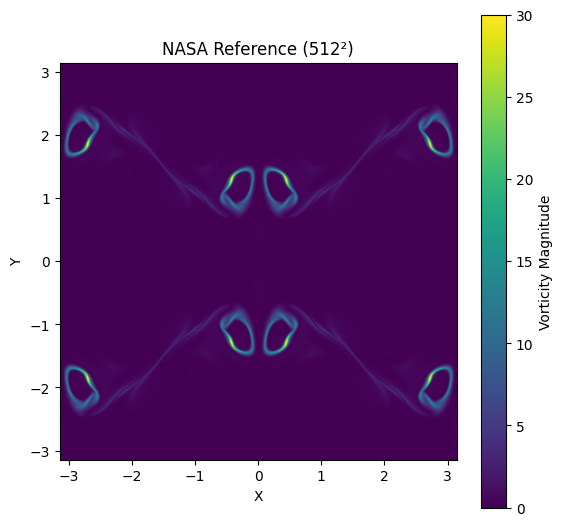

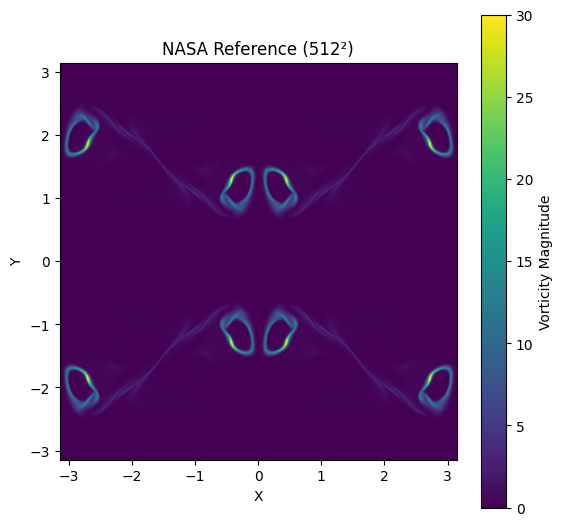

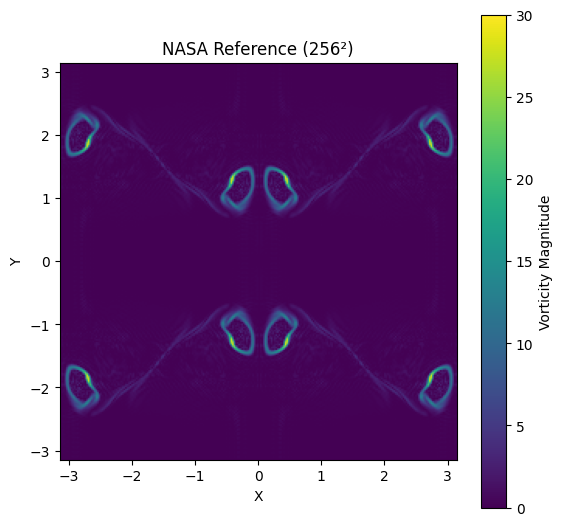

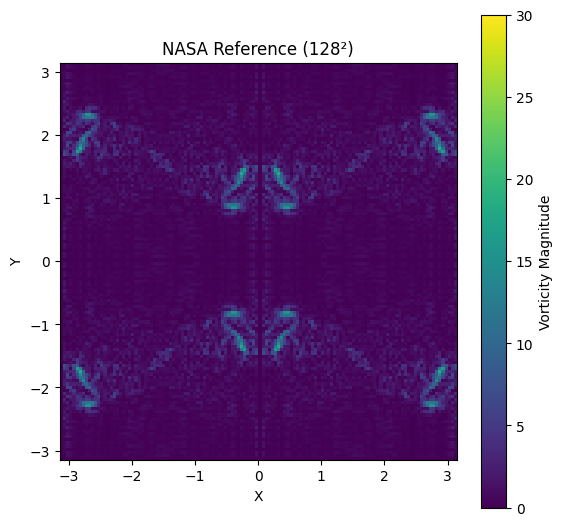

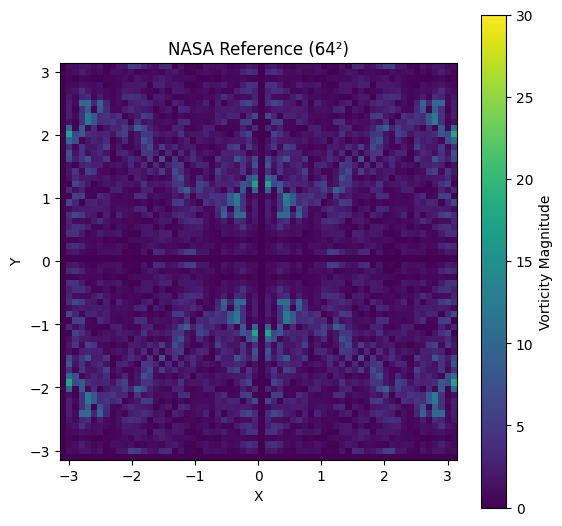

In [85]:
plt.figure(figsize=(6.4, 6.4))

im1 = plt.imshow(data_nasa, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 origin='lower', cmap='viridis', vmin=0, vmax=30)
plt.title('NASA Reference (512²)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, label='Vorticity Magnitude')

plt.show()

plt.figure(figsize=(6.4, 6.4))

im1 = plt.imshow(data_512.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 origin='lower', cmap='viridis', vmin=0, vmax=30)
plt.title('NASA Reference (512²)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, label='Vorticity Magnitude')

plt.show()


plt.figure(figsize=(6.4, 6.4))

im1 = plt.imshow(data_256.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 origin='lower', cmap='viridis', vmin=0, vmax=30)
plt.title('NASA Reference (256²)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, label='Vorticity Magnitude')

plt.show()


plt.figure(figsize=(6.4, 6.4))

im1 = plt.imshow(data_128.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 origin='lower', cmap='viridis', vmin=0, vmax=30)
plt.title('NASA Reference (128²)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, label='Vorticity Magnitude')

plt.show()


plt.figure(figsize=(6.4, 6.4))

im1 = plt.imshow(data_64.T, extent=[-np.pi, np.pi, -np.pi, np.pi], 
                 origin='lower', cmap='viridis', vmin=0, vmax=30)
plt.title('NASA Reference (64²)')
plt.xlabel('X')
plt.ylabel('Y')
plt.colorbar(im1, label='Vorticity Magnitude')

plt.show()


# Plot comparison:

## 512 comparison:

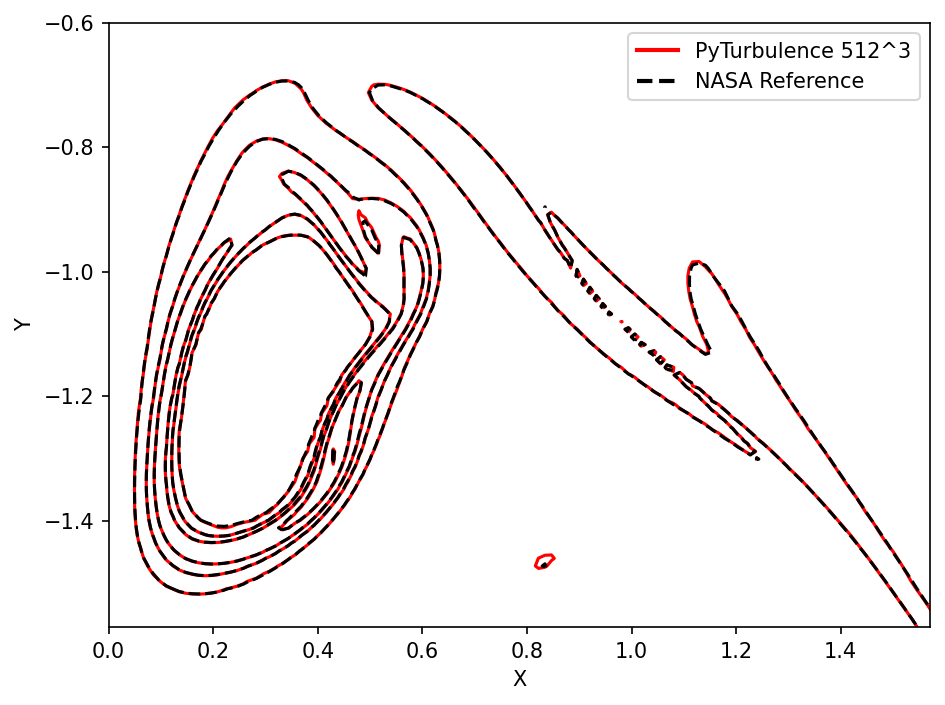

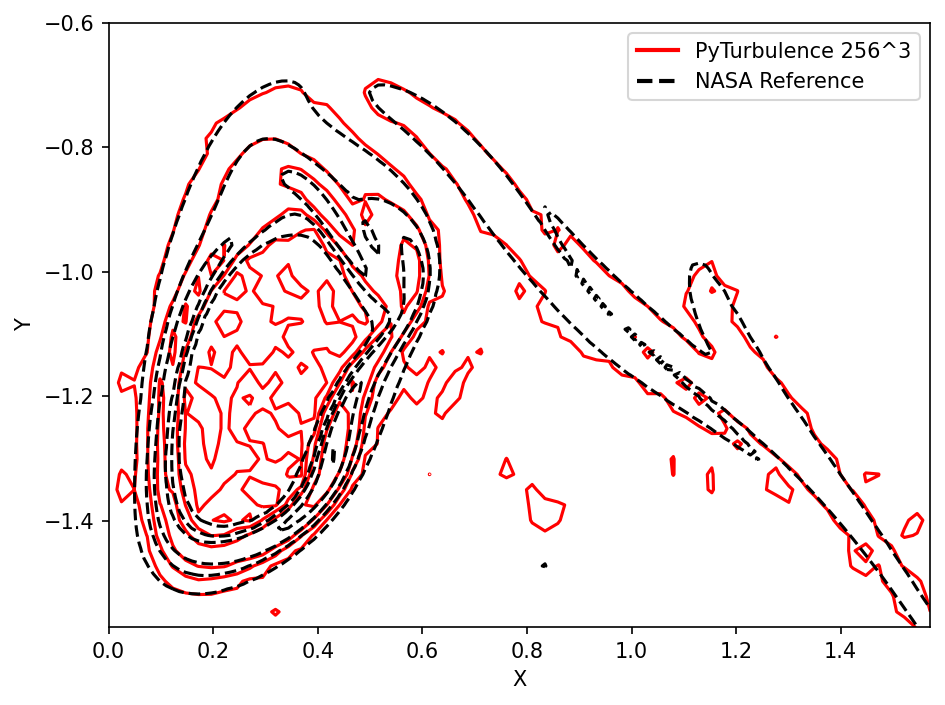

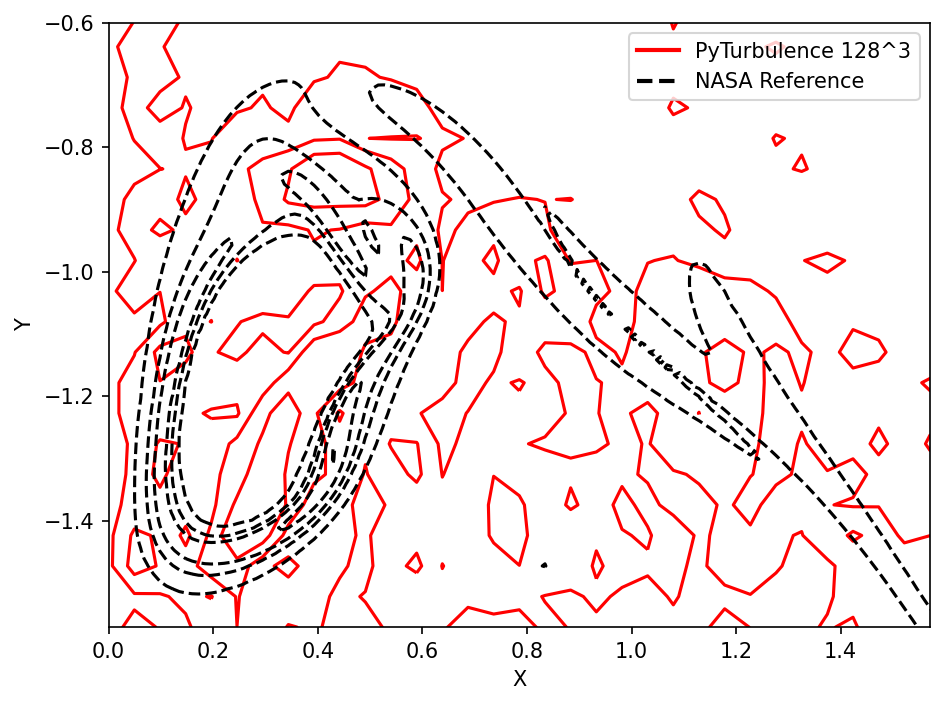

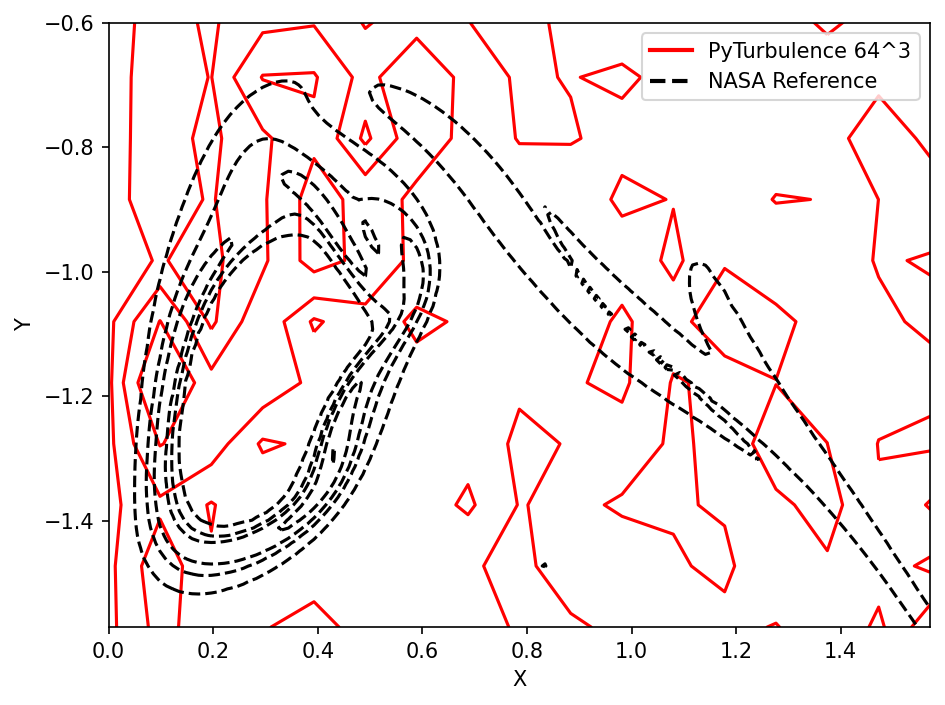

In [86]:
# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=150)

# Plot contours
ax.contour(x_512, y_512, data_512.T, levels=[1, 5, 10, 20, 30], colors="red")
ax.contour(
    x_nasa, y_nasa, data_nasa, levels=[1, 5, 10, 20, 30], colors="k", linestyles="--"
)

# Set axis limits
ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-np.pi / 2, -0.6)

# Add colorbar and labels
# plt.colorbar(contours)
ax.set_xlabel("X")
ax.set_ylabel("Y")

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="PyTurbulence 512^3"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="NASA Reference"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=150)

# Plot contours
ax.contour(x_256, y_256, data_256.T, levels=[1, 5, 10, 20, 30], colors="red")
ax.contour(
    x_nasa, y_nasa, data_nasa, levels=[1, 5, 10, 20, 30], colors="k", linestyles="--"
)

# Set axis limits
ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-np.pi / 2, -0.6)

# Add colorbar and labels
# plt.colorbar(contours)
ax.set_xlabel("X")
ax.set_ylabel("Y")

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="PyTurbulence 256^3"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="NASA Reference"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=150)

# Plot contours
ax.contour(x_128, y_128, data_128.T, levels=[1, 5, 10, 20, 30], colors="red")
ax.contour(
    x_nasa, y_nasa, data_nasa, levels=[1, 5, 10, 20, 30], colors="k", linestyles="--"
)

# Set axis limits
ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-np.pi / 2, -0.6)

# Add colorbar and labels
# plt.colorbar(contours)
ax.set_xlabel("X")
ax.set_ylabel("Y")

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="PyTurbulence 128^3"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="NASA Reference"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()


# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=150)

# Plot contours
ax.contour(x_64, y_64, data_64.T, levels=[1, 5, 10, 20, 30], colors="red")
ax.contour(
    x_nasa, y_nasa, data_nasa, levels=[1, 5, 10, 20, 30], colors="k", linestyles="--"
)

# Set axis limits
ax.set_xlim(0, np.pi / 2)
ax.set_ylim(-np.pi / 2, -0.6)

# Add colorbar and labels
# plt.colorbar(contours)
ax.set_xlabel("X")
ax.set_ylabel("Y")

legend_elements = [
    Line2D([0], [0], color="red", lw=2, label="PyTurbulence 64^3"),
    Line2D([0], [0], color="black", lw=2, linestyle="--", label="NASA Reference"),
]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

/tmp/ipykernel_67081/3809815821.py:5: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(x, y, data_512.T, levels=[1, 5, 10, 20, 30], colors='red', label='')


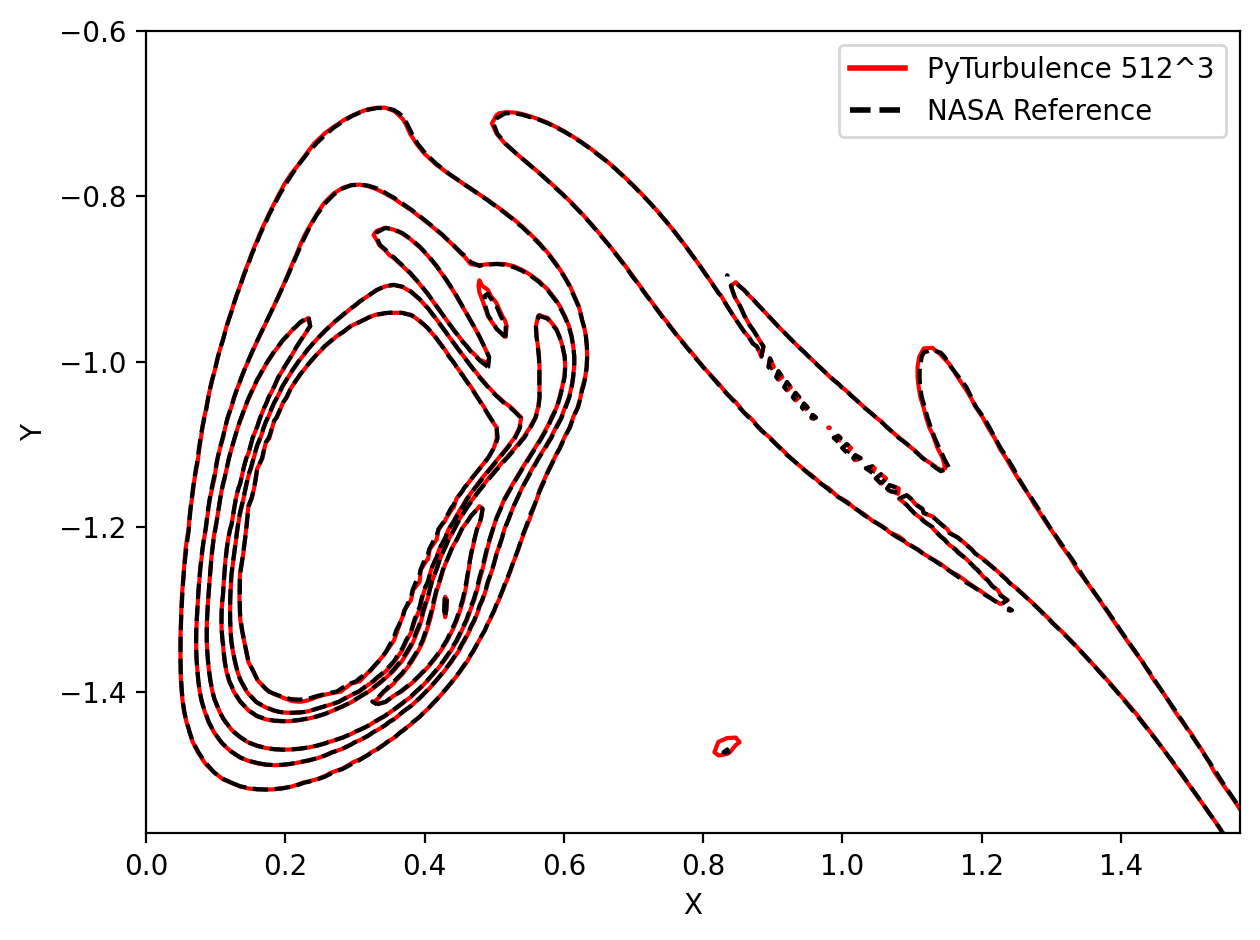

In [63]:
# Create contour plot
fig, ax = plt.subplots(figsize=(6.4, 4.8), dpi=200)

# Plot contours
ax.contour(x, y, data_512.T, levels=[1, 5, 10, 20, 30], colors='red', label='')
ax.contour(x, y, data_nasa, levels=[1, 5, 10, 20, 30], colors='k', linestyles='--')

# Set axis limits
ax.set_xlim(0, np.pi/2)
ax.set_ylim(-np.pi/2, -0.6)

# Add labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='red', lw=2, label='PyTurbulence 512^3'),
                   Line2D([0], [0], color='black', lw=2, linestyle='--', label='NASA Reference')]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

# NASA original code bkp:

## Full domain

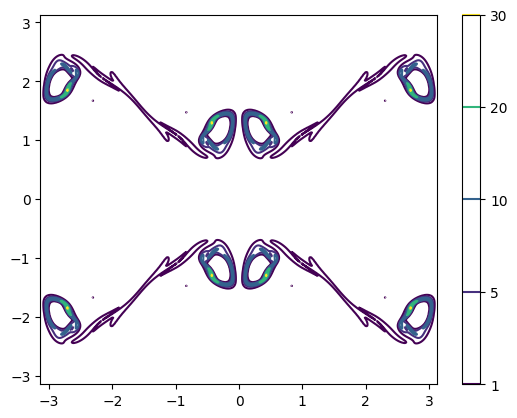

In [6]:
#! /usr/bin/env python
# -*- coding: UTF-8 -*-
# Small python script to extract and plot
# the data contained in the file wn_slice_x0_08000.out
# Other example of script:
#  f = fopen(file, "rb") ;
#  for i
#   for j
#     fread(W(i,j), 1, sizeof(double), f)
#   end
#  end


from numpy import *

import pylab as p
from struct import *

Pi = arccos(-1)
x = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)
y = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)

size = (len(x),len(y))

w = zeros(size)

file = open('../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out', 'rb')
data = file.read()

n = 0
for i in range(len(x)):
  for j in range(len(y)):
    a = unpack('d', data[n:n+8])
    w[j][i] = a[0]
    n = n+8

fig=p.figure()
p.contour(x,y,w, levels = [1,5,10,20,30])
#p.axis('normal')
p.colorbar()
p.show()


## Only the non periodic domain:

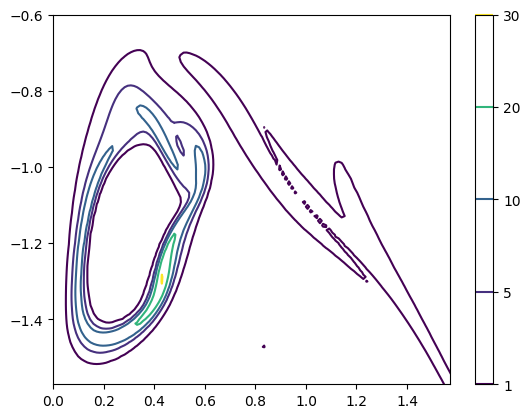

In [17]:
#! /usr/bin/env python
# -*- coding: UTF-8 -*-
# Small python script to extract and plot
# the data contained in the file wn_slice_x0_08000.out
# Other example of script:
#  f = fopen(file, "rb") ;
#  for i
#   for j
#     fread(W(i,j), 1, sizeof(double), f)
#   end
#  end


from numpy import *

import pylab as p
from struct import *

Pi = arccos(-1)
x = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)
y = arange(-Pi,Pi-2.*Pi/512.,2.*Pi/512.)

size = (len(x),len(y))

w = zeros(size)

file = open('../Data/NASA_workshop_validation/C3.3_datafiles/wn_slice_x0_08000.out', 'rb')
data = file.read()

n = 0
for i in range(len(x)):
  for j in range(len(y)):
    a = unpack('d', data[n:n+8])
    w[j][i] = a[0]
    n = n+8

fig=p.figure()

p.contour(x,y,w, levels = [1,5,10,20,30])
#p.axis('normal')

plt.xlim(0, 2*pi/4)  # Set x-axis limits
plt.ylim(-2*pi/4, -0.6)  # Set y-axis limits

p.colorbar()
p.show()
